In [1]:
!pip install yfinance statsmodels arch scipy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 19.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats as sp_stats
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import VECM, select_order, select_coint_rank
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
START = '2014-01-01'
END   = '2024-12-31'

def download_series(ticker, start, end):
    raw   = yf.download(ticker, start=start, end=end,
                        auto_adjust=True, progress=False)
    close = raw['Close']
    if isinstance(close, pd.DataFrame):
        close = close.squeeze()
    close = close.squeeze()
    close.name = ticker
    return close

print("Downloading Gold spot ETF (GOLDBEES.NS)...")
gold_etf      = download_series('GOLDBEES.NS', START, END)
gold_spot_raw = gold_etf * 10

print("Downloading USD/INR exchange rate (INR=X)...")
usd_inr       = download_series('INR=X', START, END)

print("Downloading COMEX Gold futures (GC=F)...")
gold_fut_usd  = download_series('GC=F', START, END)

# Convert COMEX futures from USD/troy oz  ->  INR/10g
# 1 troy oz = 31.1035 grams  =>  1 troy oz = 3.11035 units of 10g
TROY_OZ_PER_10G = 31.1035 / 10

# Align usd_inr to the futures trading dates before multiplying
usd_inr_aligned = usd_inr.reindex(gold_fut_usd.index).ffill()
gold_fut_inr    = gold_fut_usd * usd_inr_aligned * (1 / TROY_OZ_PER_10G)

# Verify all are genuinely 1-D before proceeding
assert gold_spot_raw.ndim == 1, f"spot is {gold_spot_raw.ndim}-D, expected 1-D"
assert usd_inr.ndim       == 1, f"usd_inr is {usd_inr.ndim}-D, expected 1-D"
assert gold_fut_inr.ndim  == 1, f"futures is {gold_fut_inr.ndim}-D, expected 1-D"

print("\nAll series confirmed 1-D. Shapes:")
print(f"  Spot ETF (INR/10g) : {gold_spot_raw.shape}")
print(f"  USD/INR rate       : {usd_inr.shape}")
print(f"  Futures (INR/10g)  : {gold_fut_inr.shape}")
print("\nSample spot values:")
print(gold_spot_raw.tail(3).to_string())


All series confirmed 1-D. Shapes:
  Spot ETF (INR/10g) : (2708,)
  USD/INR rate       : (2866,)
  Futures (INR/10g)  : (2764,)

Sample spot values:
Date
2024-12-26    640.000000
2024-12-27    642.099991
2024-12-30    640.000000


In [4]:
# ============================================================
# CELL 4 - Merge, clean and build master DataFrame
# After this cell:
#   df           : price levels with columns 'spot' and 'futures'
#   df_diff      : first differences (Delta_S and Delta_F)
#   df_logret    : daily log returns
# ============================================================

df_raw = pd.concat([gold_spot_raw.rename('spot'),
                    gold_fut_inr.rename('futures')], axis=1)
df_raw = df_raw.ffill().dropna()

futures_pct_chg = df_raw['futures'].pct_change().abs()
roll_dates = futures_pct_chg[futures_pct_chg > 0.015].index
print(f"Detected {len(roll_dates)} roll dates (jumps > 1.5%)")

futures_adj = df_raw['futures'].copy()
for rd in sorted(roll_dates, reverse=True):
    idx = df_raw.index.get_loc(rd)
    if idx == 0:
        continue
    gap = df_raw['futures'].iloc[idx] - df_raw['futures'].iloc[idx - 1]
    futures_adj.iloc[:idx] -= gap

df = pd.DataFrame({
    'spot'   : df_raw['spot'],
    'futures': futures_adj
}).dropna()

# First differences
df_diff = df.diff().dropna()

# Log returns
df_logret = np.log(df / df.shift(1)).dropna()

print(f"\nFinal df shape    : {df.shape}")
print(f"Date range        : {df.index[0].date()} to {df.index[-1].date()}")
print(f"Observations      : {len(df)}")
print("\ndf.head():")
print(df.head())
print("\ndf_diff.head():")
print(df_diff.head())

Detected 311 roll dates (jumps > 1.5%)

Final df shape    : (2848, 2)
Date range        : 2014-01-02 to 2024-12-30
Observations      : 2848

df.head():
                  spot       futures
Date                                
2014-01-02  274.605007  17541.845793
2014-01-03  276.529999  17895.859659
2014-01-06  276.270008  17951.541256
2014-01-07  276.114998  17815.100257
2014-01-08  274.004993  17642.358303

df_diff.head():
                spot     futures
Date                            
2014-01-03  1.924992  354.013866
2014-01-06 -0.259991   55.681597
2014-01-07 -0.155010 -136.440999
2014-01-08 -2.110004 -172.741953
2014-01-09  0.290012   95.644685


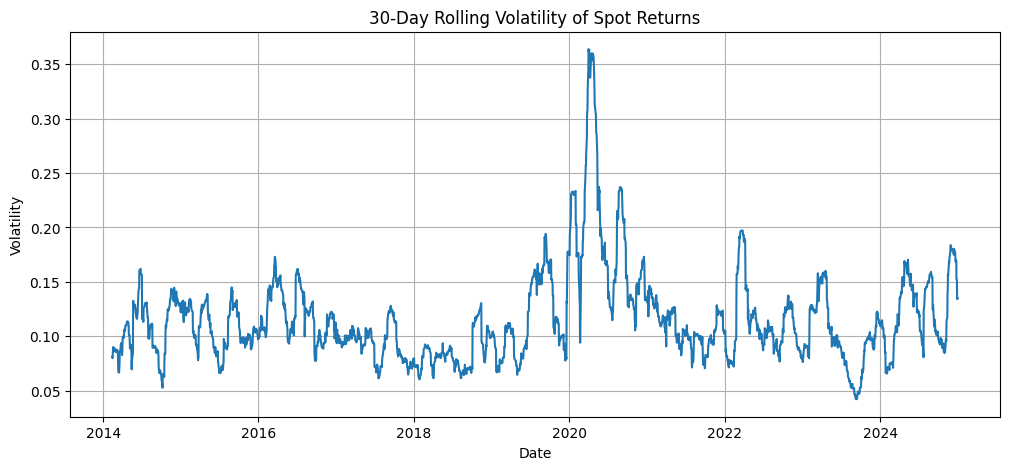

In [5]:
# log returns
df['r_spot'] = np.log(df['spot'] / df['spot'].shift(1))
df['r_fut']  = np.log(df['futures'] / df['futures'].shift(1))

df = df.dropna()

# remove extreme outliers
df['r_spot'] = df['r_spot'].clip(lower=df['r_spot'].quantile(0.001), upper=df['r_spot'].quantile(0.999))
df['r_fut']  = df['r_fut'].clip(lower=df['r_fut'].quantile(0.001), upper=df['r_fut'].quantile(0.999))

# 30-day rolling volatility
window = 30
df['vol_30'] = df['r_spot'].rolling(window).std() * np.sqrt(252)

plt.figure(figsize=(12,5))
plt.plot(df.index, df['vol_30'])
plt.title('30-Day Rolling Volatility of Spot Returns')
plt.ylabel('Volatility')
plt.xlabel('Date')
plt.grid(True)
# plt.show()

plt.savefig('fig1_rolling_volatility.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
from arch import arch_model

# GARCH(1,1)
garch11 = arch_model(df['r_spot']*100, vol='GARCH', p=1, q=1, mean='Constant')
res_garch11 = garch11.fit()

print(res_garch11.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 19289.046008191413
Iteration:      2,   Func. Count:     15,   Neg. LLF: 229497385739.5984
Iteration:      3,   Func. Count:     23,   Neg. LLF: 3787.0703660458685
Iteration:      4,   Func. Count:     31,   Neg. LLF: 3516.63977375248
Iteration:      5,   Func. Count:     38,   Neg. LLF: 3130.210402511335
Iteration:      6,   Func. Count:     44,   Neg. LLF: 3129.2125950668296
Iteration:      7,   Func. Count:     49,   Neg. LLF: 3129.2109376295966
Iteration:      8,   Func. Count:     54,   Neg. LLF: 3129.210740384853
Iteration:      9,   Func. Count:     59,   Neg. LLF: 3129.2107378287424
Iteration:     10,   Func. Count:     63,   Neg. LLF: 3129.2107378285887
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3129.2107378287424
            Iterations: 10
            Function evaluations: 63
            Gradient evaluations: 10
                     Constant Mean - GARCH Model Results         

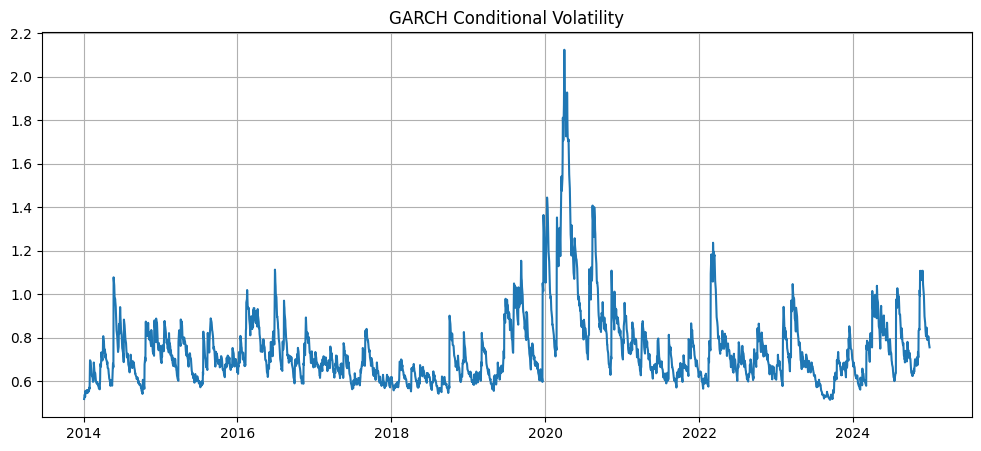

In [7]:
cond_vol = res_garch11.conditional_volatility

plt.figure(figsize=(12,5))
plt.plot(df.index, cond_vol)
plt.title("GARCH Conditional Volatility")
plt.grid(True)

plt.savefig('fig2_garch_volatility.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
alpha = res_garch11.params['alpha[1]']
beta  = res_garch11.params['beta[1]']
print("alpha: ", alpha)
print("beta: ", beta)
print("Persistence (alpha + beta):", alpha + beta)

alpha:  0.05602621520189318
beta:  0.9087551261075377
Persistence (alpha + beta): 0.9647813413094309


In [9]:
import statsmodels.api as sm
from arch import arch_model

# We scale it back down by dividing by 100. it acts as a proxy for epsilon t
df['resid_sq'] = (res_garch11.resid / 100)**2

# volatility of futures market recently
df['fut_activity'] = df['r_fut'].rolling(5).std()

# epsilon squared at time=t-1
df['resid_sq_lag'] = df['resid_sq'].shift(1)
df_var = df.dropna(subset=['resid_sq', 'resid_sq_lag', 'fut_activity'])

# 5. run regression with following variables
X = df_var[['resid_sq_lag', 'fut_activity']]
X = sm.add_constant(X) # adds a column of ones.
y = df_var['resid_sq']

model_var = sm.OLS(y, X).fit()
print("\n--- Part (c): Variance Equation Test (Two-Stage OLS) ---")
print(model_var.summary())


--- Part (c): Variance Equation Test (Two-Stage OLS) ---
                            OLS Regression Results                            
Dep. Variable:               resid_sq   R-squared:                       0.087
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     135.1
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           9.20e-57
Time:                        15:53:00   Log-Likelihood:                 21261.
No. Observations:                2843   AIC:                        -4.252e+04
Df Residuals:                    2840   BIC:                        -4.250e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

In [10]:
threshold = df['fut_activity'].median()

high = df[df['fut_activity'] > threshold]
low  = df[df['fut_activity'] <= threshold]

# annualized volality for both high and low
vol_high = high['r_spot'].std() * np.sqrt(252)
vol_low  = low['r_spot'].std() * np.sqrt(252)

print("Volatility during HIGH futures activity:", vol_high)
print("Volatility during LOW futures activity :", vol_low)

Volatility during HIGH futures activity: 0.141889433260951
Volatility during LOW futures activity : 0.098522264203233


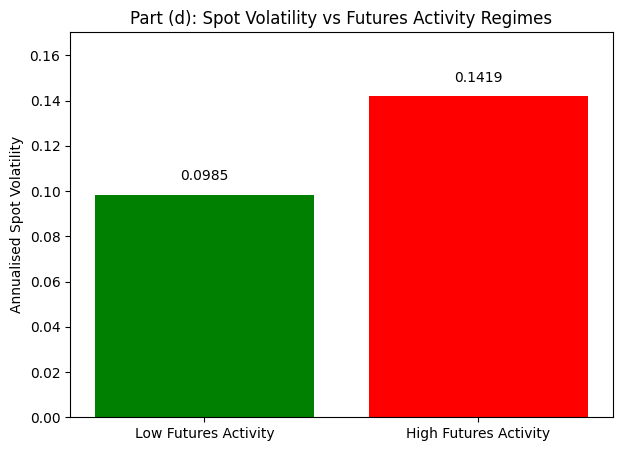

In [11]:
# Plot
plt.figure(figsize=(7, 5))
bars = plt.bar(['Low Futures Activity', 'High Futures Activity'], [vol_low, vol_high], color=['green', 'red'])
plt.title('Part (d): Spot Volatility vs Futures Activity Regimes')
plt.ylabel('Annualised Spot Volatility')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.4f}", ha='center', va='bottom')

plt.ylim(0, max(vol_low, vol_high) * 1.2)
plt.savefig('fig3_regime_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
